In [31]:
import pydicom as dc
import os
import matplotlib.pyplot as plt
import numpy as np
# import pandas as pd

In [27]:
folder = r'D:\UNCP\SEMILLEROS\PROYECTO\PRUEBAS\1348 RAMIREZ ACAPANA TEODORO VICTOR\34303\CT Cuerpo 1.0'
file = 'CT000200.dcm'
file_1 = "CT000200.dcm"
file_2 = "CT000102.dcm"
file_3 = "CT000490.dcm"

In [28]:
dicom = dc.dcmread(os.path.join(folder, file))
dicom_1 = dc.dcmread(os.path.join(folder, file_1))
dicom_2 = dc.dcmread(os.path.join(folder, file_2))
dicom_3 = dc.dcmread(os.path.join(folder, file_3))

In [4]:
print("=========== PIXEL SPACING =============")
print(dicom.PixelSpacing)
print(dicom_1.PixelSpacing)
print(dicom_2.PixelSpacing)
print(dicom_3.PixelSpacing)


print("=========== SLICE THICKNESS =============")
print(dicom.SliceThickness)
print(dicom_1.SliceThickness)
print(dicom_2.SliceThickness)
print(dicom_3.SliceThickness)



=========== PIXEL SPACING =============
[0.820, 0.820]
[0.820, 0.820]
[0.820, 0.820]
[0.820, 0.820]
=========== SLICE THICKNESS =============
1.0
1.0
1.0
1.0


In [5]:
dicom

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.392.200036.9116.2.6.1.44063.1804765929.1714009659.671832
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.4
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_364'
-------------------------------------------------
(0008,0000) Group Length                        UL: 462
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.392.200036.9116.2.6.1.44063.1804765929.1714009659.671832
(0008,0020) Study Date                         

In [29]:
array_d1 = dicom_1 .pixel_array
array_d1.shape

(512, 512)

<function matplotlib.pyplot.show(close=None, block=None)>

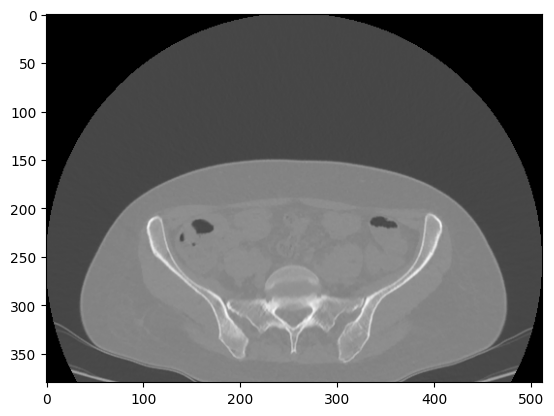

In [30]:
plt.imshow(array_d1[:380,:], cmap="gray")
plt.show

In [33]:
from skimage import io, img_as_float
from skimage.restoration import denoise_nl_means, denoise_bilateral
from skimage.filters import gaussian, median
import matplotlib.pyplot as plt


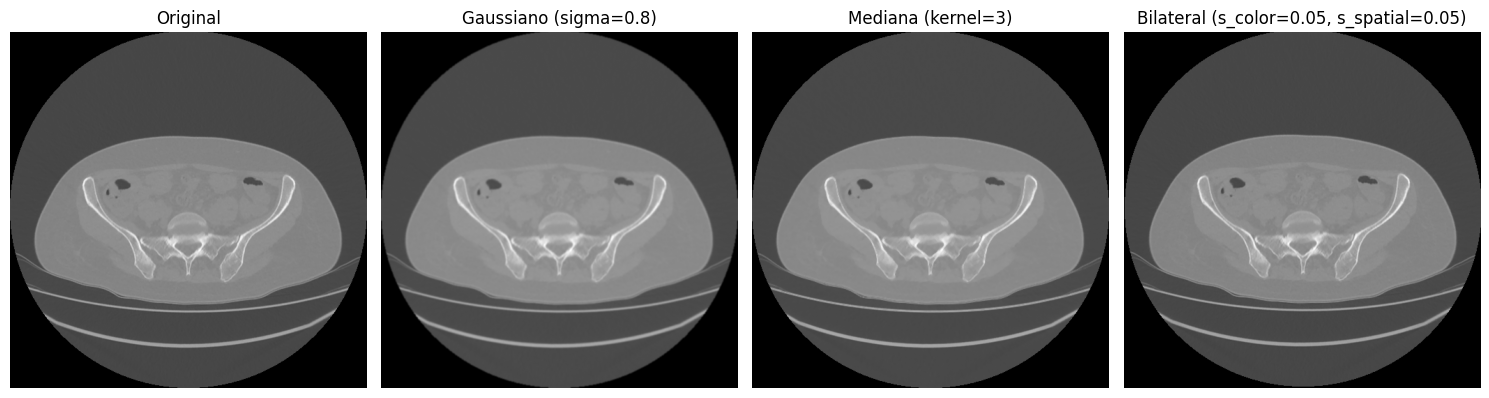

In [44]:

# Asegurarse de que la imagen sea de punto flotante para algunos filtros
img_float = img_as_float(dicom.pixel_array)

# --- Aplicar diferentes filtros de ruido ---

# 1. Filtro Gaussiano
sigma_gaussian = 0.8 # Ajusta este valor
img_gaussian = gaussian(img_float, sigma=sigma_gaussian, channel_axis=None) # channel_axis=None para imágenes en escala de grises

# 2. Filtro de Mediana
# El tamaño del kernel (vecindad) debe ser impar
kernel_median = 3
img_median = median(img_float, footprint=np.ones((kernel_median, kernel_median)))

# 3. Filtro Bilateral
# sigma_color: cuanto más grande, más píxeles se mezclan para formar el nuevo valor,
#              siempre que su valor sea lo suficientemente cercano.
# sigma_spatial: cuanto más grande, más píxeles se mezclan para formar el nuevo valor,
#                independientemente de su valor.
sigma_color_bilateral = 0.05
sigma_spatial_bilateral = 0.05

img_bilateral = denoise_bilateral(img_float, sigma_color=sigma_color_bilateral,
                                  sigma_spatial=sigma_spatial_bilateral)
                                #   multichannel=False) # multichannel=False para imágenes en escala de grises

# --- Visualización de resultados ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(dicom.pixel_array, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_gaussian, cmap='gray')
plt.title(f'Gaussiano (sigma={sigma_gaussian})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_median, cmap='gray')
plt.title(f'Mediana (kernel={kernel_median})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_bilateral, cmap='gray')
plt.title(f'Bilateral (s_color={sigma_color_bilateral}, s_spatial={sigma_spatial_bilateral})')
plt.axis('off')

plt.tight_layout()
plt.show()